# NL-1 aside — where does the self-supervised error come from?

*A companion to [NL-1](nl1-test-time-learning.ipynb), built to answer one question: test-time learning updates the memory by gradient descent on a "self-supervised" loss — but at test time we have no ground-truth labels. So where does the error signal come from? Optional: read it when NL-1 §1 points here.*

Runs on CPU in seconds; pure PyTorch, no GPU. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/nested-learning/nl1-aside-self-supervision.ipynb)

The answer has **two levels**, and the whole point is to see them side by side in a tiny, CPU-only toy:

- **Inner loss — self-supervised, no labels.** The memory's update target is *manufactured from the input token itself*. It runs every forward pass, including test time. No `y` anywhere.
- **Outer loss — supervised, real labels.** Used only during *training*, to learn the projections that *define* the inner task — i.e. to teach the label-free inner loop **what is worth memorizing**.


## The resolution, in one paragraph

In [NL-1](nl1-test-time-learning.ipynb) §1 the inner loss is $\ell(W;x_t)=\lVert f_W(\mathbf k_t)-\mathbf v_t\rVert^2$ with $\mathbf k_t=\theta_K x_t$ and $\mathbf v_t=\theta_V x_t$ — **both views of the same token**. So the "label" $\mathbf v_t$ is a projection of the input, not external supervision: the memory is asked to map one view of the token to another, and the error is just *how badly it currently does that* (Titans' "surprise"). That needs no ground truth.

But then *why does memorizing $\mathbf k_t\!\to\!\mathbf v_t$ help anything?* Because a **separate outer loss**, with real labels, runs at training time and shapes $\theta_K,\theta_V$ so that storing those particular views turns out useful for the real task. Two losses, two timescales:

| | inner loss | outer loss |
|---|---|---|
| objective | $\lVert f_W(\mathbf k_t)-\mathbf v_t\rVert^2$ (reconstruction) | the real task loss |
| supervision | **self-made from $x_t$ — no labels** | **ground-truth labels** |
| updates | the fast memory $W$ | the slow projections $\theta_K,\theta_V,\dots$ |
| when | every forward pass (incl. test time) | training only |

We'll build a toy with *both* and show the killer fact: the **same** label-free inner loop is useless with random projections and useful after the outer loop has trained them.

## The toy: in-context associative recall

A clean task that needs memory and has an obvious outer label. Each **episode**:

- has $m$ random key→value pairs $(\mathbf k_i,\mathbf v_i)$, $\mathbf k_i,\mathbf v_i\in\mathbb R^d$ — a *fresh, random* lookup table, so the model cannot bake it into weights; it must *store it in the memory at test time*;
- presents each pair as a single **token** $x_i = R\,[\mathbf k_i;\mathbf v_i]$ — key and value concatenated, then scrambled by a fixed unknown rotation $R$, so the model must *learn* how to extract the key view and the value view;
- ends with a **query** token $x_q = R\,[\mathbf k_j;\mathbf 0]$ (a key, value-part zeroed). The **outer label** is the matching value $\mathbf v_j$.

The memory reads the pair-tokens (inner loop, no labels), then we query it; the outer loss checks the recall against $\mathbf v_j$.

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

torch.manual_seed(0)
d, m = 6, 2  # value/key dim; pairs per episode (well under capacity d)
n = 2 * d  # token dim = [key ; value]
Rmix, _ = torch.linalg.qr(torch.randn(n, n))  # fixed "world" scrambling of (key, value)


def episode(g):
    K = F.normalize(torch.randn(m, d, generator=g), dim=1)  # m keys
    Vv = torch.randn(m, d, generator=g)  # m values (the random lookup table)
    X = (Rmix @ torch.cat([K, Vv], dim=1).t()).t()  # m scrambled pair-tokens (m x n)
    j = torch.randint(m, (1,), generator=g).item()  # which key we'll be quizzed on
    xq = Rmix @ torch.cat([K[j], torch.zeros(d)])  # query token: key present, value zeroed
    return X, xq, Vv[j]  # tokens, query, ground-truth answer (outer label)


X, xq, y = episode(torch.Generator().manual_seed(99))
print(
    "episode:",
    X.shape[0],
    "pair-tokens of dim",
    X.shape[1],
    "(scrambled [key;value]);  1 query;  1 label y",
)
print(
    "a token mixes key & value -> the model must LEARN to extract each view:",
    tuple(X[0].shape),
)

episode: 2 pair-tokens of dim 12 (scrambled [key;value]);  1 query;  1 label y
a token mixes key & value -> the model must LEARN to extract each view: (12,)


## The two losses, in code

`memory()` is the **inner loop**. Read it carefully: it takes the tokens and the projections, and **never sees `y`**. Its update target `v` is a projection of the token — that is the entire self-supervised signal. The **outer loss** is a separate function that *does* use `y`.

In [ ]:
def inner_loss(W, k, v):
    return ((W @ k - v) ** 2).sum()  # self-supervised: v is a VIEW of the token, not a label


def memory(X, xq, tK, tV, eta=1.0):
    # Inner loop: build the fast memory W from the tokens alone. NO label y is used here.
    W = torch.zeros(d, d)
    trace = []
    for x in X:
        k = F.normalize(tK @ x, dim=0)  # key view of the token
        v = tV @ x  # value view of the SAME token (the 'target')
        trace.append(inner_loss(W, k, v))  # surprise on this token (computed without y)
        W = W + eta * torch.outer(v - W @ k, k)  # = one GD step on inner_loss (the delta write)
    kq = F.normalize(tK @ xq, dim=0)
    return W @ kq, torch.stack(trace)  # recall prediction, inner-loss trace


def outer_loss(pred, y):
    return ((pred - y) ** 2).mean()  # supervised: y IS the held-out ground-truth value


def fresh_proj(scale=0.5, seed=0):  # slow weights = projections defining what to store
    g = torch.Generator().manual_seed(seed)
    return (torch.randn(d, n, generator=g) * scale).requires_grad_(True), (
        torch.randn(d, n, generator=g) * scale
    ).requires_grad_(True)


print("inner_loss uses (W, k, v) -- no y.   outer_loss uses (pred, y) -- the label.")

inner_loss uses (W, k, v) -- no y.   outer_loss uses (pred, y) -- the label.


## A. Random projections: the inner loop runs, but recall fails

Before any training, run the exact same label-free inner loop with *random* $\theta_K,\theta_V$. The inner losses are perfectly well-defined (no `y` needed) and the memory does store *something* — but it's the wrong something, so recall is no better than noise (relative error $\approx 1$).

In [ ]:
def mean_recall_err(tK, tV, seed, nep=300):
    g = torch.Generator().manual_seed(seed)
    tot = 0.0
    for _ in range(nep):
        X, xq, y = episode(g)
        pred, _ = memory(X, xq, tK, tV)
        tot += ((pred - y).norm() / y.norm()).item()
    return tot / nep


tK, tV = fresh_proj(seed=3)
X, xq, y = episode(torch.Generator().manual_seed(99))
pred, trace = memory(X, xq, tK, tV)
print(
    "inner losses per token (computed with NO label):",
    [round(t.item(), 2) for t in trace],
)
print(
    f"outer recall error on held-out episodes (random projections): {mean_recall_err(tK, tV, seed=7):.2f}"
)
print(
    "=> the self-supervised loop is happily running; it just hasn't been told what's worth storing."
)

inner losses per token (computed with NO label): [4.66, 3.37]
outer recall error on held-out episodes (random projections): 1.22
=> the self-supervised loop is happily running; it just hasn't been told what's worth storing.


## B. The outer loop teaches it what to store

Now train **only** the projections $\theta_K,\theta_V$ on the *outer* loss (the labeled recall error), backpropagating **through the inner memory updates** — exactly [M5](../../foundations/m5-meta-learning-self-reference.ipynb)'s MAML move (gradients flow through the inner steps; here the delta write is differentiable, so a plain `.backward()` reaches the projections). The fast memory $W$ is still built by the same label-free inner loop; we are only learning *what views to feed it*.

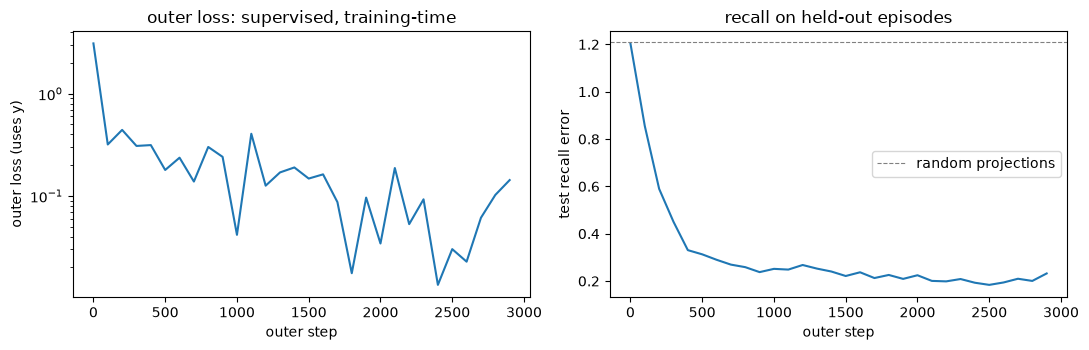

recall error  random 1.20  ->  trained 0.23  (1.0 = noise)


In [ ]:
tK, tV = fresh_proj(seed=3)
opt = torch.optim.Adam([tK, tV], lr=1e-2)
g = torch.Generator().manual_seed(1)
outer_curve, recall_curve, steps = [], [], []
for it in range(3000):
    opt.zero_grad()
    L = 0.0
    for _ in range(8):  # a batch of episodes
        X, xq, y = episode(g)
        pred, _ = memory(X, xq, tK, tV)  # inner loop (no y) ...
        L = L + outer_loss(pred, y)  # ... scored by the outer loss (y)
    (L / 8).backward()
    opt.step()  # trains the PROJECTIONS through the inner updates
    if it % 100 == 0:
        outer_curve.append((L / 8).item())
        steps.append(it)
        recall_curve.append(mean_recall_err(tK.detach(), tV.detach(), seed=7, nep=60))

rand_baseline = mean_recall_err(*fresh_proj(seed=3), seed=7, nep=60)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(steps, outer_curve)
a1.set_xlabel("outer step")
a1.set_ylabel("outer loss (uses y)")
a1.set_title("outer loss: supervised, training-time")
a1.set_yscale("log")
a2.plot(steps, recall_curve)
a2.set_xlabel("outer step")
a2.set_ylabel("test recall error")
a2.set_title("recall on held-out episodes")
a2.axhline(rand_baseline, ls="--", c="gray", lw=0.8, label="random projections")
a2.legend()
plt.tight_layout()
plt.show()
print(
    f"recall error  random {recall_curve[0]:.2f}  ->  trained {recall_curve[-1]:.2f}  (1.0 = noise)"
)

## C. At test time: only the label-free inner loop runs

The payoff. On **fresh** episodes the model has never seen, we run *just* the inner loop — no labels, no outer loss, no gradient on the projections — and recall works. The memory learns each new random lookup table at test time, purely from the tokens.

In [ ]:
tKf, tVf = tK.detach(), tV.detach()
print(
    f"mean test recall error, brand-new episodes (inner loop only, NO labels): "
    f"{mean_recall_err(tKf, tVf, seed=12345):.2f}   (random projections were ~{rand_baseline:.2f})"
)

# a few fresh episodes, end to end -- the inner loop never touches y
g = torch.Generator().manual_seed(2024)
errs = []
for _ in range(6):
    X, xq, y = episode(g)
    pred, trace = memory(X, xq, tKf, tVf)  # builds memory from tokens alone, then recalls
    errs.append(((pred - y).norm() / y.norm()).item())
print("6 fresh episodes, recall relative error:", [round(e, 2) for e in errs])
print(f"last episode's inner losses while reading (no y): {[round(t.item(), 1) for t in trace]}")
print("no label was used to BUILD or QUERY the memory -- the tokens supervised themselves.")

mean test recall error, brand-new episodes (inner loop only, NO labels): 0.24   (random projections were ~1.21)
6 fresh episodes, recall relative error: [0.67, 0.1, 0.11, 0.27, 0.57, 0.15]
last episode's inner losses while reading (no y): [2.6, 1.8]
no label was used to BUILD or QUERY the memory -- the tokens supervised themselves.


## So — where does the error come from?

**From the data, twice, at two levels:**

1. **Inner (self-supervised, no labels).** The update target is a *view of the input token* ($\mathbf v_t=\theta_V x_t$). The error is the memory's own reconstruction/recall error on that view — well-defined with zero ground truth. This is what runs at **test time**, and it's how the memory "learns the sequence on the fly." (In §A you saw it run even with random projections.)
2. **Outer (supervised, real labels).** A separate task loss, with ground truth, runs at **training time** and shapes the projections $\theta_K,\theta_V$ — i.e. it teaches the label-free inner loop *what to extract and store*. (In §B that's what turned a useless inner loop into a working one: recall went from $\approx 1$ to well below it, with the inner mechanism unchanged.)

Two earlier modules are exactly these two levels:

- the inner loop is **[NL-1](nl1-test-time-learning.ipynb) §1's TTT write** — $\mathbf k_t,\mathbf v_t=\theta_K x_t,\theta_V x_t$, memory updated by a GD step on $\lVert f_W(\mathbf k_t)-\mathbf v_t\rVert^2$;
- training it by backprop **through** those inner updates is **[M5](../../foundations/m5-meta-learning-self-reference.ipynb)'s MAML** — outer gradients flow through an inner optimization.

So "test-time learning" never needed labels at test time: the data supervises itself in the inner loop, and the labels did their job earlier, in the outer loop, deciding what that self-supervision should target. *(A second, even more intuitive flavor of the same idea: in next-token prediction the future of the stream is the label for its past — the sequence supervises itself one step late. Same principle, different view.)*